# LIME Analysis - Bipolar HiPIMS Deposition Rates

This notebook generates LIME (Local Interpretable Model-agnostic Explanations) for XGBoost models trained on Bipolar HiPIMS deposition rate data. It follows the same workflow as `Pickle SHAP datasets example.ipynb` but uses LIME instead of SHAP for model interpretability.

In [3]:
import json, os, pickle, importlib
import numpy as np
import pandas as pd
import baybe
import optuna
from pathlib import Path
import matplotlib.pyplot as plt

import InitializeCampaign as ic
from src.hipims_bo_utils import prepare_campaign_df, get_ipk
from src.xgb_training.utils import campaign_split_test_train, train_final_model, evaluate_model, plot_parity
from src.xgb_training.optimization import create_objective, EarlyStoppingCallback
import src.lime_utils
importlib.reload(src.lime_utils)  # reload to pick up any changes
from src.lime_utils import (
    create_lime_explainer, explain_all_samples, save_lime_explanations,
    load_lime_explanations, lime_dependence_plot, lime_importance_barplot,
    lime_waterfall_plot, compare_shap_lime_importance
)

## 1. Define Data Paths

Set up paths to all campaign folders. Each folder contains a `Campaign.json`, `calibration.txt`, and `Logfile - Oscilloscope/` directory.

In [4]:
HEAD_PATH = Path(r"Bipolar Datasets - Al and Ti - low and high PW\Datasets Used for Publication")

folder_list = [
    "Al - 120 W  - short PW",
    "Al - 200 W - high PW",
    "Al - 250 W - duty cycle series",
    "Ti - 120 W - short PW",
    "Ti - 200 W - high PW",
    "Ti 250 W low duty cycle",
]

# Output directory for pickled LIME explanations
LIME_PICKLE_DIR = Path("Pickles/LIME")
LIME_PICKLE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load and Process Raw Data

For each campaign folder:
1. Load `Campaign.json` and `calibration.txt`
2. Extract peak current (Ipk) from oscilloscope logfiles
3. Build a clean DataFrame with the desired feature set
4. Re-initialize a BayBE Campaign with the clean data

In [5]:
import base64

def _long_path(p):
    """Prepend \\\\?\\ to an absolute path to bypass Windows 260-char limit.
    Works with drive-letter paths (G:\\...), NOT UNC paths."""
    s = os.path.abspath(str(p))
    if not s.startswith("\\\\?\\"):
        s = "\\\\?\\" + s
    return s

def get_ipk_safe(path, corr_time, campaign):
    """Local version of get_ipk that uses open()+json.load() instead of pd.read_json()
    to handle Windows long paths on network drives."""
    Ipk_list = []
    idx = 0
    df_campaign = campaign.measurements
    path_str = _long_path(path)
    for file in sorted(os.listdir(path_str)):
        with open(path_str + "\\" + file, 'r') as f:
            data = json.load(f)
        df = pd.DataFrame(data)
        df.columns = df.columns.astype(int)  # json.load gives string keys; match pd.read_json behavior

        # Create adjusted time
        df['Time'] = np.linspace(0, int(len(df) * corr_time), len(df))

        # Define triggers
        trigger = 900 * corr_time
        trigger_exclude = 250 * corr_time
        cutoff_trigger = trigger + trigger_exclude
        cutoff_pulse = cutoff_trigger + df_campaign['PW (us)'].iloc[idx]

        # Use defined triggers for Ipk determination
        df_mask = df.loc[(df['Time'] > cutoff_trigger) & (df['Time'] < cutoff_pulse)]
        Ipk_list.append(np.max(df_mask[2]) / 45.58)  # A/cm² for 3" target
        idx += 1

    return Ipk_list

campaigns = {}  # store processed campaigns keyed by folder name
CAMPAIGN_CACHE_DIR = Path("Pickles/LIME/campaigns")
CAMPAIGN_CACHE_DIR.mkdir(parents=True, exist_ok=True)

for folder_name in folder_list:
    print(f"\n--- Loading: {folder_name} ---")
    FOLDER_PATH = HEAD_PATH / folder_name
    CAMPAIGN_PATH = _long_path(FOLDER_PATH / 'Campaign.json')
    OSCCI_PATH = FOLDER_PATH / 'Logfile - Oscilloscope'

    # Load campaign data from double-encoded JSON
    raw = open(CAMPAIGN_PATH).read()
    campaign_dict = json.loads(json.loads(raw))

    # Extract parameter names and measurements
    param_names = [p['name'] for p in campaign_dict['searchspace']['continuous']['parameters']]
    df_measurements = pickle.loads(base64.b64decode(campaign_dict['_measurements_exp']))

    # Build a fresh campaign with these params
    lower_bounds_orig = [df_measurements[p].min() for p in param_names]
    upper_bounds_orig = [df_measurements[p].max() for p in param_names]
    campaign = ic.init_campaign(lower_bounds_orig, upper_bounds_orig, param_names)
    campaign.add_measurements(df_measurements[param_names + ['y1']])

    # Load calibration
    df_cal = pd.read_csv(_long_path(FOLDER_PATH / 'calibration.txt'))
    us_window = int(df_cal['us-window'].iloc[0])
    dep_rate_calibration = float(df_cal[' dep-rate calibration'].iloc[0])

    # Compute time correction factor
    corr_time = us_window / 10000  # us/point (10,000 sampled points)

    # Extract Ipk from oscilloscope logfiles
    Ipk_list = get_ipk_safe(OSCCI_PATH, corr_time, campaign)

    # Build clean DataFrame
    df_campaign = prepare_campaign_df(campaign, dep_rate_calibration, Ipk_list)

    # Define feature params for LIME analysis
    params = ['Ipk (A)', 'PW (us)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']
    if 'PRR (Hz)' in df_campaign.columns:
        params.insert(2, 'PRR (Hz)')

    # Compute bounds and re-initialize campaign with desired features
    lower_bounds = [df_campaign[p].min() for p in params]
    upper_bounds = [df_campaign[p].max() for p in params]
    new_campaign = ic.init_campaign(lower_bounds, upper_bounds, params)

    # Build clean df with only desired params + target
    df_clean = df_campaign[params + ['y1']].copy()
    new_campaign.add_measurements(df_clean)

    campaigns[folder_name] = new_campaign

    # Cache the processed campaign data so Step 2 can be skipped next time
    cache_path = CAMPAIGN_CACHE_DIR / f"{folder_name}.pkl"
    with open(cache_path, 'wb') as f:
        pickle.dump({'campaign': new_campaign, 'params': params}, f)

    print(f"Loaded: {len(df_clean)} samples, params={params}")

print(f"\nCached all campaigns to {CAMPAIGN_CACHE_DIR}/")


--- Loading: Al - 120 W  - short PW ---


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(
c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Loaded: 601 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']

--- Loading: Al - 200 W - high PW ---


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(
c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Loaded: 651 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']

--- Loading: Al - 250 W - duty cycle series ---


...

Loaded: 495 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']

--- Loading: Ti - 200 W - high PW ---


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(
c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Loaded: 601 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']

--- Loading: Ti 250 W low duty cycle ---


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(
c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Loaded: 401 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']

Cached all campaigns to Pickles\LIME\campaigns/


### 2b. Load cached campaign data (skip Step 2 if caches exist)

Run this cell instead of Step 2 if you've already processed the raw data once. It loads the cached campaigns from `Pickles/LIME/campaigns/`.

In [6]:
import pickle
from pathlib import Path

CAMPAIGN_CACHE_DIR = Path("Pickles/LIME/campaigns")

campaigns = {}
for pkl_file in sorted(CAMPAIGN_CACHE_DIR.glob("*.pkl")):
    folder_name = pkl_file.stem
    with open(pkl_file, 'rb') as f:
        cached = pickle.load(f)
    campaigns[folder_name] = cached['campaign']
    print(f"Loaded '{folder_name}': {len(cached['campaign'].measurements)} samples, params={cached['params']}")

print(f"\nLoaded {len(campaigns)} campaigns from cache.")

Loaded 'Al - 120 W  - short PW': 601 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']
Loaded 'Al - 200 W - high PW': 651 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']
Loaded 'Al - 250 W - duty cycle series': 401 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']
Loaded 'Ti - 120 W - short PW': 495 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']
Loaded 'Ti - 200 W - high PW': 601 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']
Loaded 'Ti 250 W low duty cycle': 401 samples, params=['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']

Loaded 6 campaigns from cache.


## 3. Fit BayBE GPR and Generate LIME Explanations

For each campaign, we use the **same BayBE GPR surrogate** (botorch `SingleTaskGP`) that underlies the SHAP explanations. LIME is model-agnostic — it only needs a predict function, so we wrap `model.posterior().mean` and pass it to LIME. This ensures that any differences between SHAP and LIME scatter plots are purely due to the explanation method, not the underlying model.

For each campaign:
1. Split into train/test sets
2. Fit BayBE GPR surrogate on training data
3. Evaluate train/test R² and RMSE
4. Create LIME explainer and explain all samples
5. Save LIME explanations as pickle files

In [7]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Ensure output directory exists
LIME_PICKLE_DIR = Path("Pickles/LIME")
LIME_PICKLE_DIR.mkdir(parents=True, exist_ok=True)


def make_gpr_predict_fn(model, params):
    """Wrap BayBE GPR posterior as a LIME-compatible predict function.
    
    LIME passes raw numpy arrays; this converts them to a DataFrame
    with named columns so model.posterior() works correctly.
    """
    def predict_fn(X_array):
        df = pd.DataFrame(X_array, columns=params)
        with torch.no_grad():
            return model.posterior(df).mean.detach().numpy().flatten()
    return predict_fn


lime_results = {}
model_metrics = []

for folder_name, campaign in campaigns.items():
    print(f"\n{'='*60}")
    print(f"Processing: {folder_name}")
    print(f"{'='*60}")

    df = campaign.measurements
    params = [p.name for p in campaign.parameters]
    X = df[params]
    y = df['y1']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    # Recombine for adding measurements to temp campaign
    df_train = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
    df_test = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

    # Fit BayBE GPR on training data
    model = campaign.get_surrogate()
    model.fit(campaign.searchspace, campaign.objective, df_train)

    # Evaluate on train and test
    with torch.no_grad():
        y_train_pred = model.posterior(df_train[params]).mean.detach().numpy().flatten()
        y_test_pred = model.posterior(df_test[params]).mean.detach().numpy().flatten()

    r2_train = r2_score(df_train['y1'].values, y_train_pred)
    r2_test = r2_score(df_test['y1'].values, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(df_train['y1'].values, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(df_test['y1'].values, y_test_pred))

    print(f"Train RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}")
    print(f"Test  RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}")
    print(f"Gap:  {r2_train - r2_test:.4f}")

    model_metrics.append({
        'Dataset': folder_name,
        'Train R²': round(r2_train, 4),
        'Test R²': round(r2_test, 4),
        'Gap': round(r2_train - r2_test, 4),
        'Train RMSE': round(rmse_train, 4),
        'Test RMSE': round(rmse_test, 4),
        'N_samples': len(df),
    })

    # Create LIME predict function wrapping the GPR
    predict_fn = make_gpr_predict_fn(model, params)

    # Create LIME explainer and explain all samples
    X_all = pd.concat([X_train, X_test], ignore_index=True)
    y_all = pd.concat([y_train, y_test], ignore_index=True)

    explainer = create_lime_explainer(X_train[params], params)
    df_lime, explanations = explain_all_samples(
        explainer, predict_fn, X_all[params], num_features=len(params)
    )

    # Save LIME explanations
    output_path = LIME_PICKLE_DIR / f"{folder_name}.pkl"
    save_lime_explanations(df_lime, explanations, output_path, extra={
        'model': model,
        'X_train': X_train, 'X_test': X_test, 'X_all': X_all,
        'y_train': y_train, 'y_test': y_test, 'y_all': y_all,
        'feature_names': params,
        'all_feature_names': params,
        'metrics': {'r2_train': r2_train, 'r2_test': r2_test,
                    'rmse_train': rmse_train, 'rmse_test': rmse_test},
    })
    print(f"Saved to {output_path}")

    lime_results[folder_name] = {
        'df_lime': df_lime,
        'explanations': explanations,
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'X_all': X_all,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': params,
        'all_feature_names': params,
        'metrics': {'r2_train': r2_train, 'r2_test': r2_test,
                    'rmse_train': rmse_train, 'rmse_test': rmse_test},
    }

# Print summary table
print(f"\n{'='*60}")
print("GPR Model Fit Summary")
print(f"{'='*60}")
df_metrics = pd.DataFrame(model_metrics)
print(df_metrics.to_string(index=False))


Processing: Al - 120 W  - short PW
Train RMSE: 0.0922, R²: 0.8729
Test  RMSE: 0.1004, R²: 0.8298
Gap:  0.0430
Saved to Pickles\LIME\Al - 120 W  - short PW.pkl

Processing: Al - 200 W - high PW
Train RMSE: 0.0451, R²: 0.9491
Test  RMSE: 0.1433, R²: 0.5630
Gap:  0.3861
Saved to Pickles\LIME\Al - 200 W - high PW.pkl

Processing: Al - 250 W - duty cycle series
Train RMSE: 0.2635, R²: 0.7796
Test  RMSE: 0.2974, R²: 0.6624
Gap:  0.1172
Saved to Pickles\LIME\Al - 250 W - duty cycle series.pkl

Processing: Ti - 120 W - short PW
Train RMSE: 0.0701, R²: 0.8242
Test  RMSE: 0.0812, R²: 0.7865
Gap:  0.0376
Saved to Pickles\LIME\Ti - 120 W - short PW.pkl

Processing: Ti - 200 W - high PW
Train RMSE: 0.0644, R²: 0.6777
Test  RMSE: 0.0739, R²: 0.5799
Gap:  0.0978
Saved to Pickles\LIME\Ti - 200 W - high PW.pkl

Processing: Ti 250 W low duty cycle
Train RMSE: 0.1702, R²: 0.7164
Test  RMSE: 0.1696, R²: 0.7146
Gap:  0.0019
Saved to Pickles\LIME\Ti 250 W low duty cycle.pkl

GPR Model Fit Summary
         

### Load saved LIME explanations (skip to here if pickles already exist)

In [8]:
from src.lime_utils import load_lime_explanations

LIME_PICKLE_DIR = Path("Pickles/LIME")

lime_results = {}
model_metrics = []

for pkl_file in sorted(LIME_PICKLE_DIR.glob("*.pkl")):
    folder_name = pkl_file.stem
    data = load_lime_explanations(pkl_file)
    lime_results[folder_name] = data

    # Print metrics if available
    m = data.get('metrics')
    if m:
        model_metrics.append({
            'Dataset': folder_name,
            'Train R²': round(m['r2_train'], 4),
            'Test R²': round(m['r2_test'], 4),
            'Train RMSE': round(m['rmse_train'], 4),
            'Test RMSE': round(m['rmse_test'], 4),
        })

    print(f"Loaded '{folder_name}': {len(data['df_lime'])} samples")

if model_metrics:
    print(f"\n{'='*60}")
    print("Model Fit Summary")
    print(f"{'='*60}")
    print(pd.DataFrame(model_metrics).to_string(index=False))
else:
    print("\nNote: Pickles were saved without metrics/model. Re-run Step 3 to generate them.")

Loaded 'Al - 120 W  - short PW': 601 samples
Loaded 'Al - 200 W - high PW': 651 samples
Loaded 'Al - 250 W - duty cycle series': 401 samples
Loaded 'Ti - 120 W - short PW': 495 samples
Loaded 'Ti - 200 W - high PW': 601 samples
Loaded 'Ti 250 W low duty cycle': 401 samples

Model Fit Summary
                       Dataset  Train R²  Test R²  Train RMSE  Test RMSE
        Al - 120 W  - short PW    0.8729   0.8298      0.0922     0.1004
          Al - 200 W - high PW    0.9491   0.5630      0.0451     0.1433
Al - 250 W - duty cycle series    0.7796   0.6624      0.2635     0.2974
         Ti - 120 W - short PW    0.8242   0.7865      0.0701     0.0812
          Ti - 200 W - high PW    0.6777   0.5799      0.0644     0.0739
       Ti 250 W low duty cycle    0.7164   0.7146      0.1702     0.1696


## 4. Visualize LIME Results

### 4.1 Model Parity Plots

## 3b. Cross-Validated Train/Test Gap (BayBE GPR)

To provide a model-consistent cross-validation, we use the same BayBE GPR surrogate (botorch `SingleTaskGP`) that underlies the SHAP explanations. This allows direct comparison of the GPR's generalization performance alongside the XGBoost-based LIME analysis above.

In [9]:
import torch
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

cv_summary = []

for folder_name, campaign in campaigns.items():
    df = campaign.measurements
    params = [p.name for p in campaign.parameters]

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):
        df_train = df.iloc[train_idx].reset_index(drop=True)
        df_test = df.iloc[test_idx].reset_index(drop=True)

        model = campaign.get_surrogate()
        model.fit(campaign.searchspace, campaign.objective, df_train)

        with torch.no_grad():
            y_pred_train = model.posterior(df_train[params]).mean.detach().numpy().flatten()
            y_pred_test = model.posterior(df_test[params]).mean.detach().numpy().flatten()

        r2_train = r2_score(df_train['y1'].values, y_pred_train)
        r2_test = r2_score(df_test['y1'].values, y_pred_test)
        rmse_test = np.sqrt(mean_squared_error(df_test['y1'].values, y_pred_test))

        fold_results.append({
            'R2_train': r2_train,
            'R2_test': r2_test,
            'Gap': r2_train - r2_test,
            'RMSE_test': rmse_test,
        })

    r2_trains = [f['R2_train'] for f in fold_results]
    r2_tests = [f['R2_test'] for f in fold_results]
    gaps = [f['Gap'] for f in fold_results]
    rmses = [f['RMSE_test'] for f in fold_results]

    cv_summary.append({
        'Dataset': folder_name,
        'Train R²': f"{np.mean(r2_trains):.3f} ± {np.std(r2_trains):.3f}",
        'Test R²': f"{np.mean(r2_tests):.3f} ± {np.std(r2_tests):.3f}",
        'R² Gap': f"{np.mean(gaps):.3f} ± {np.std(gaps):.3f}",
        'Test RMSE': f"{np.mean(rmses):.4f} ± {np.std(rmses):.4f}",
    })

df_cv = pd.DataFrame(cv_summary)
print("BayBE GPR 5-Fold Cross-Validation Summary")
print("=" * 80)
df_cv

BayBE GPR 5-Fold Cross-Validation Summary


,Dataset,Train R²,Test R²,R² Gap,Test RMSE
0,Al - 120 W - short PW,0.872 ± 0.006,0.821 ± 0.039,0.051 ± 0.045,0.1058 ± 0.0035
1,Al - 200 W - high PW,0.926 ± 0.042,0.789 ± 0.148,0.138 ± 0.178,0.0880 ± 0.0363
2,Al - 250 W - duty cycle series,0.784 ± 0.010,0.703 ± 0.047,0.081 ± 0.054,0.2956 ± 0.0407
3,Ti - 120 W - short PW,0.847 ± 0.016,0.740 ± 0.063,0.107 ± 0.079,0.0841 ± 0.0057
4,Ti - 200 W - high PW,0.669 ± 0.012,0.611 ± 0.058,0.058 ± 0.069,0.0704 ± 0.0046
5,Ti 250 W low duty cycle,0.741 ± 0.019,0.648 ± 0.048,0.093 ± 0.066,0.1881 ± 0.0293


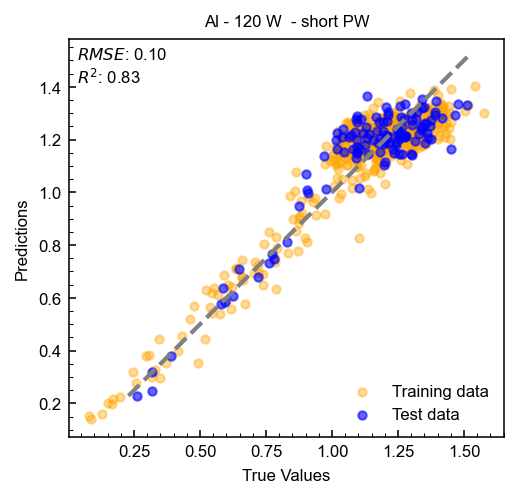

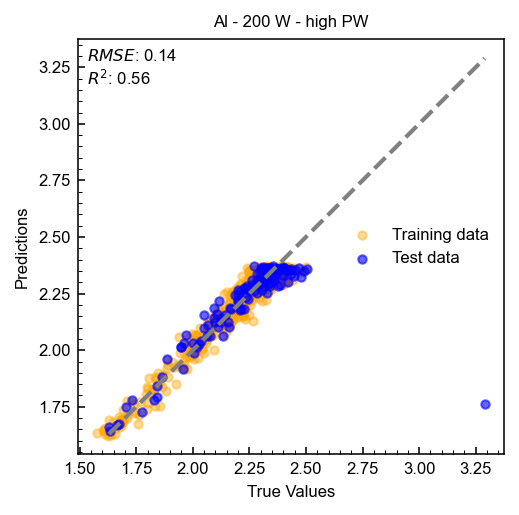

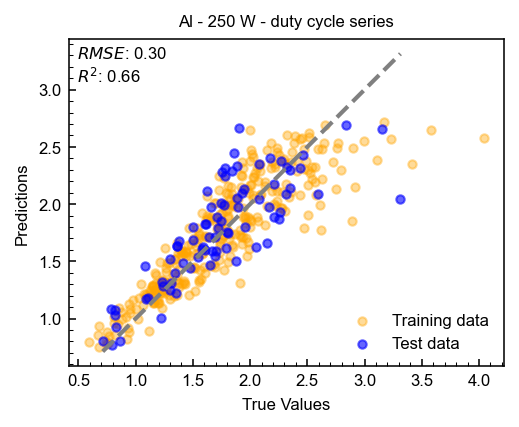

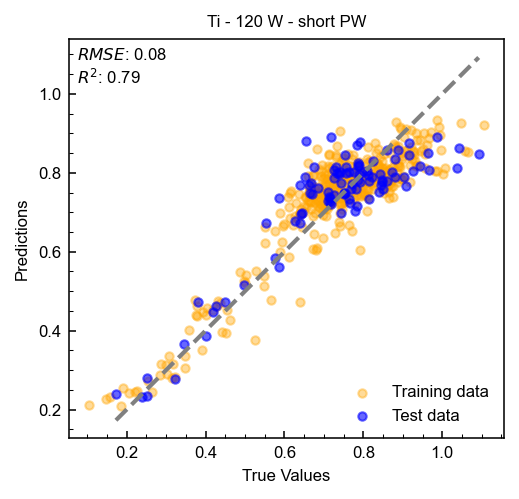

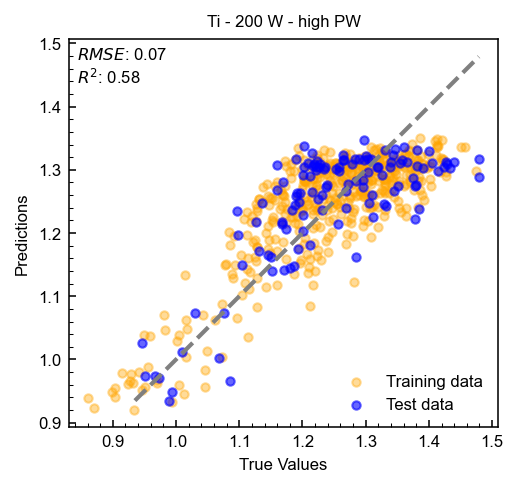

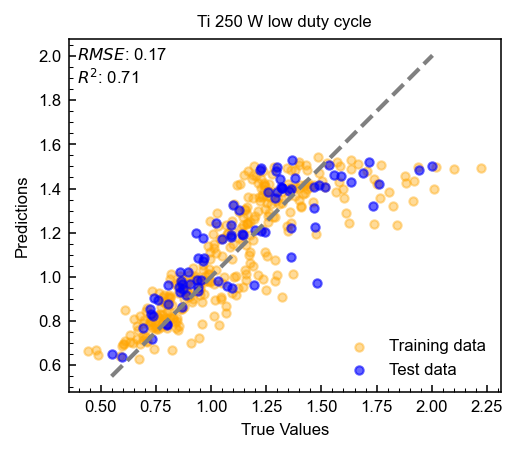

In [10]:
# Parity plots using GPR posterior predictions
for folder_name, res in lime_results.items():
    if 'model' not in res:
        print(f"Skipping '{folder_name}' — no model (re-run Step 3)")
        continue
    model = res['model']
    params = res['feature_names']

    with torch.no_grad():
        y_train_pred = model.posterior(res['X_train'][params]).mean.detach().numpy().flatten()
        y_test_pred = model.posterior(res['X_test'][params]).mean.detach().numpy().flatten()

    ax = plot_parity(res['y_train'], y_train_pred, res['y_test'], y_test_pred, scaled=False)
    ax.set_title(folder_name)
    plt.show()

### 4.2 LIME Feature Importance (Mean |Coefficient|)

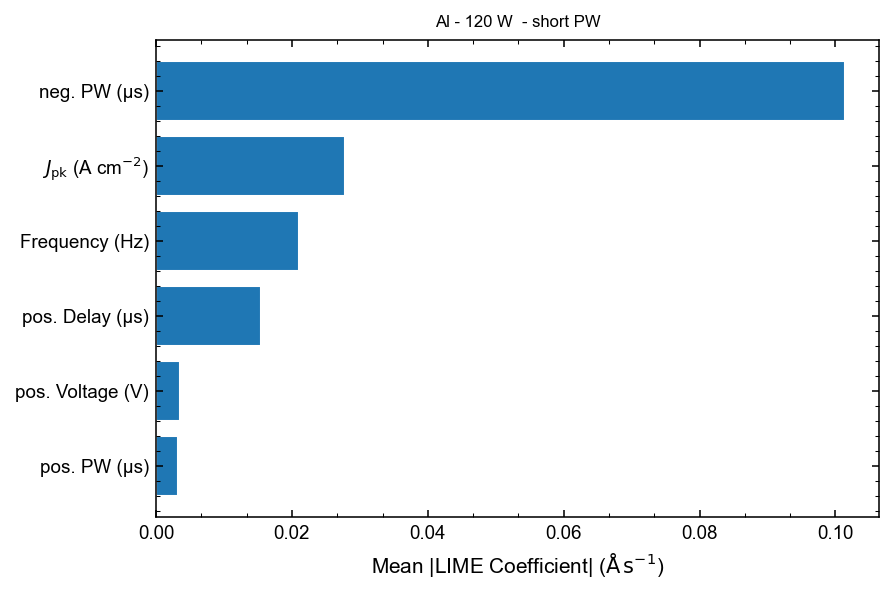

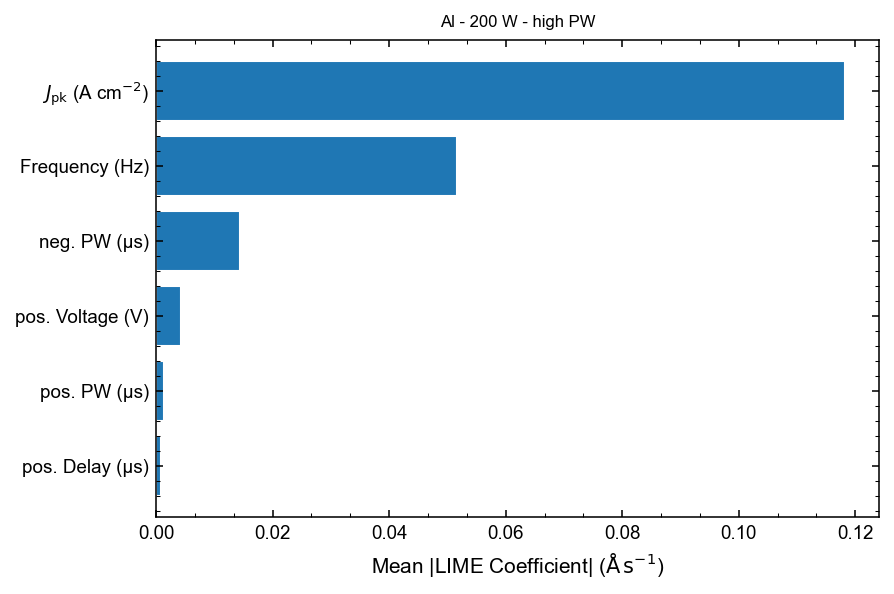

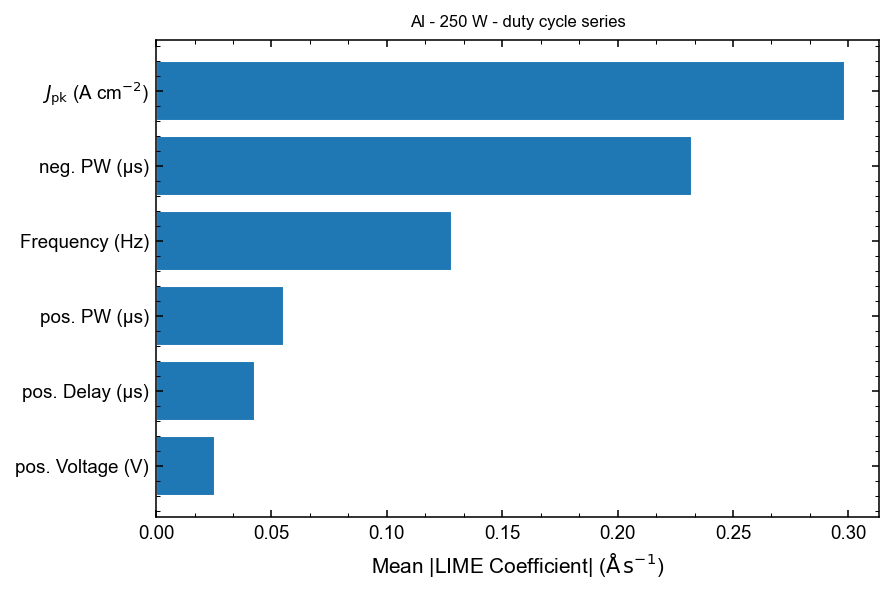

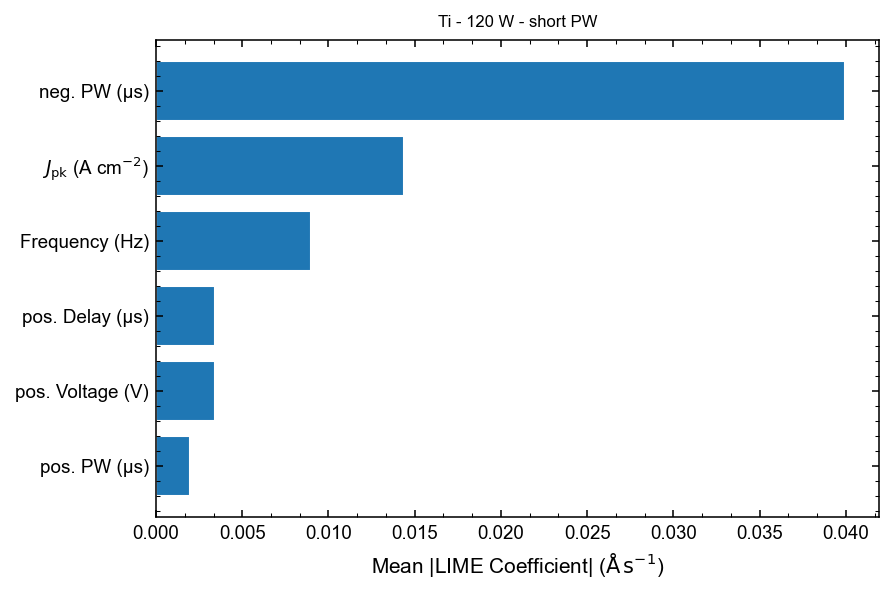

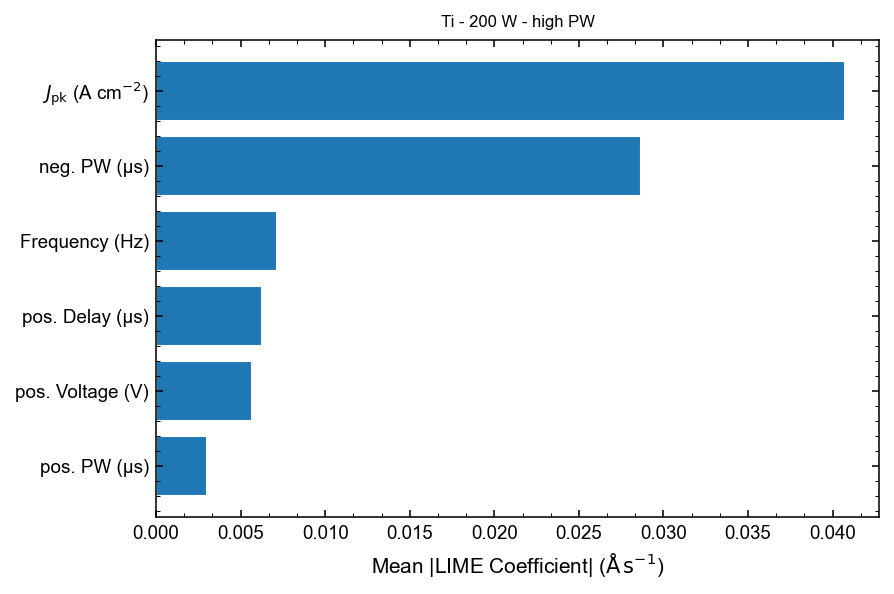

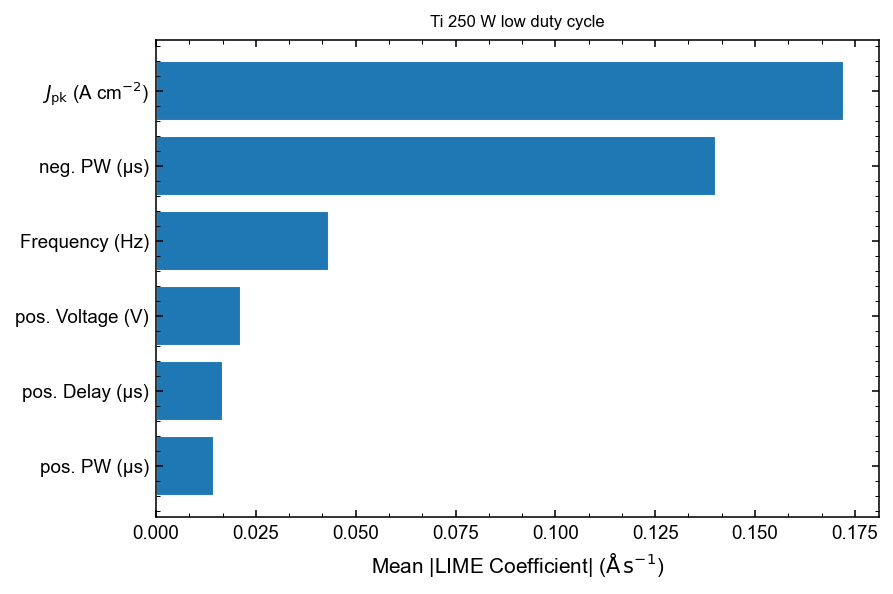

In [11]:
for folder_name, res in lime_results.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    lime_importance_barplot(res['df_lime'], ax, feature_names=res['feature_names'])
    ax.set_title(folder_name)
    plt.tight_layout()
    plt.show()

### 4.3 LIME Coefficient vs Process Parameter Scatter Plots

For each dataset, shows all 6 (or 5) process parameters side by side. X-axis: parameter value, Y-axis: LIME coefficient for that parameter.

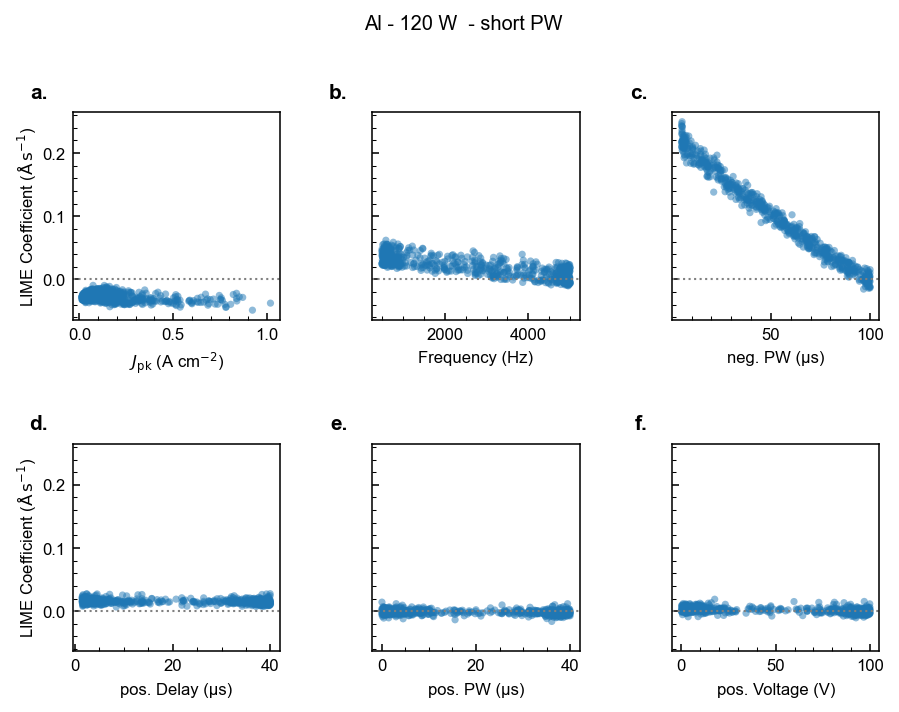

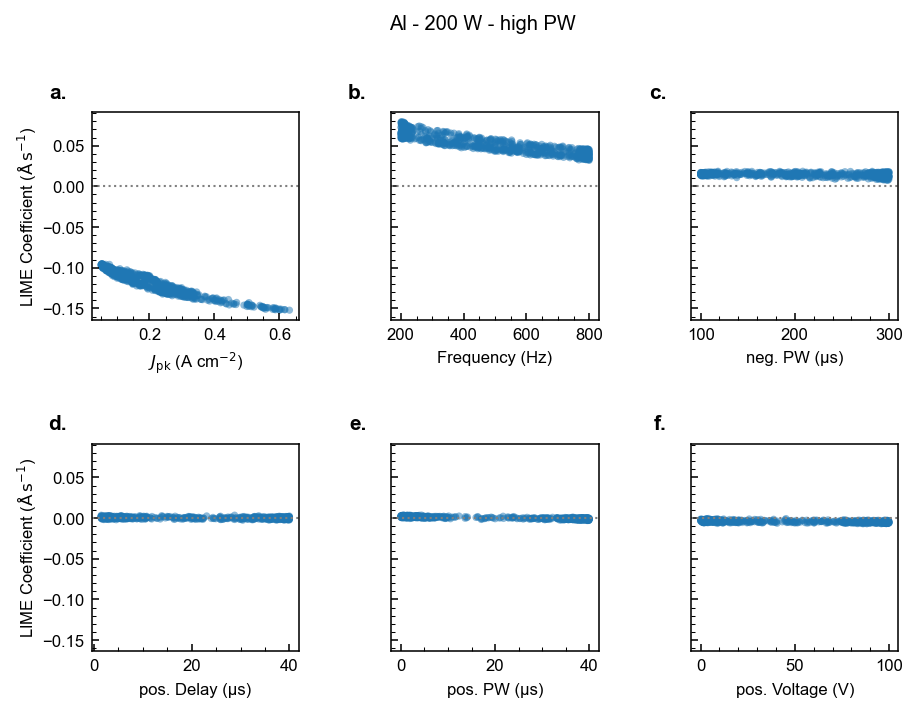

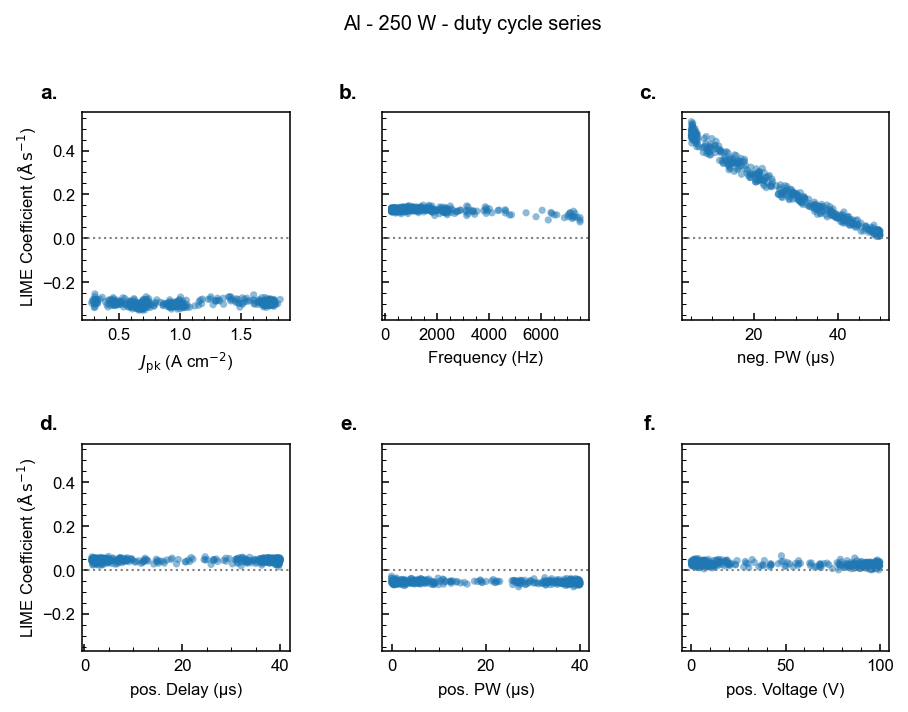

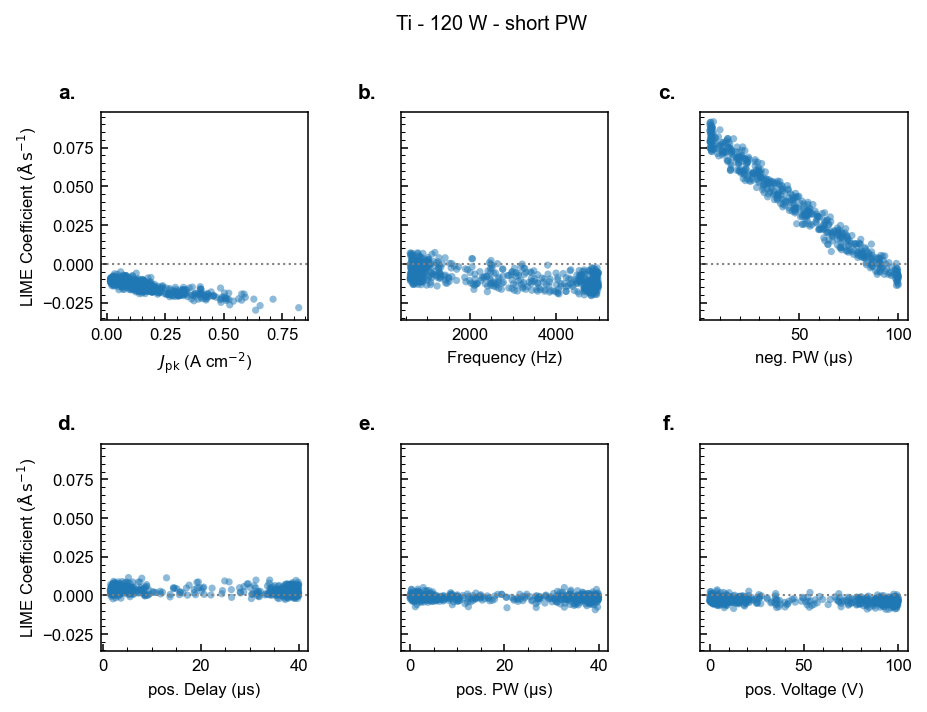

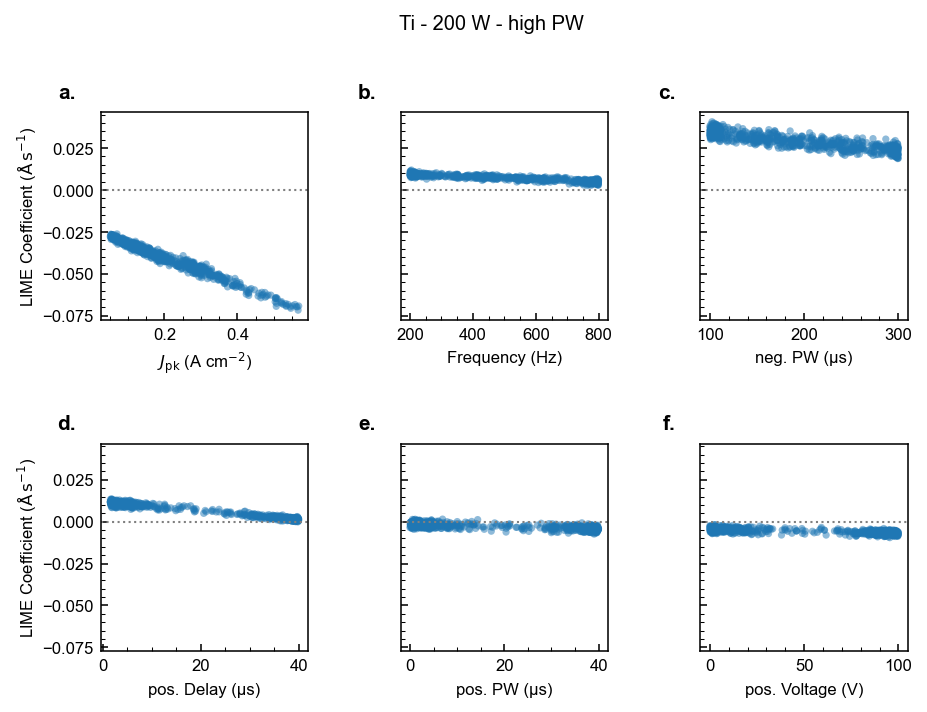

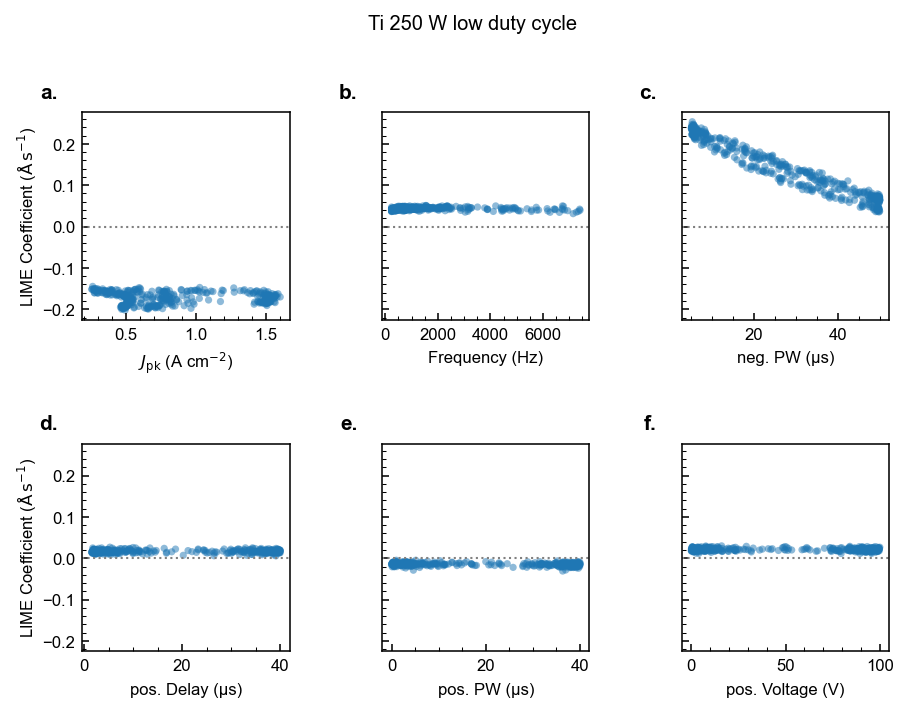

In [12]:
import sys
sys.path.insert(0, r'C:\Users\rona\pubfig')

import matplotlib.pyplot as plt
plt.style.use('publication')
from pubfig import figure, multipanel, colorbar, savefig

from pathlib import Path
IMG_DIR = Path.cwd() / 'images'
IMG_DIR.mkdir(exist_ok=True)

from src.shap_utils import names as feature_display_names

LIME_YLABEL = r'LIME Coefficient ($\mathrm{\AA\,s^{-1}}$)'

for folder_name, res in lime_results.items():
    if res.get('X_all') is None:
        print(f"Skipping '{folder_name}' — no raw feature data (loaded from old pickle)")
        continue

    feature_names = res['feature_names']
    df_lime = res['df_lime']
    X_all = res['X_all']
    n = len(feature_names)

    # Compute shared y-axis limits across all features for this dataset
    y_vals = [df_lime[feat].values for feat in feature_names]
    shared_ymin = min(v.min() for v in y_vals)
    shared_ymax = max(v.max() for v in y_vals)
    y_margin = (shared_ymax - shared_ymin) * 0.05
    shared_ylim = (shared_ymin - y_margin, shared_ymax + y_margin)

    fig, axes = multipanel(2, 3, columns=2)

    for i, feat in enumerate(feature_names):
        ax = axes.flat[i]
        ax.scatter(X_all[feat], df_lime[feat], s=12, alpha=0.5, edgecolors='none')
        ax.axhline(0, color='grey', linestyle=':', linewidth=1)
        ax.set_xlabel(feature_display_names.get(feat, feat))
        ax.set_ylim(shared_ylim)
        ax.yaxis.labelpad = 2
        if i % 3 == 0:
            ax.set_ylabel(LIME_YLABEL)
        else:
            ax.set_yticklabels([])
            ax.set_ylabel('')
        ax.set_box_aspect(1)

    # Hide unused axes
    for i in range(n, 6):
        axes.flat[i].set_visible(False)

    fig.suptitle(folder_name, y=1.02)
    fig.subplots_adjust(hspace=0.6, wspace=0.4)
    savefig(fig, str(IMG_DIR / f'lime_scatter_{folder_name.replace(" ", "_")}'))
    plt.show()